In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.datasets import make_regression
import smogn
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_excel('Time to Rupture.xlsx')
data1 = pd.read_excel('generated_data_inverse.xlsx')

In [3]:
X_Ori = data.iloc[:,:-1]
X_Aug = data1.iloc[:,:-1]
y_Ori = data.iloc[:,-1]
y_Aug = data1.iloc[:,-1]
X_Ori['source'] = 'Real Data'
X_Aug['source'] = 'Extrapolated Data'

In [4]:
# 合并数据
X_combined = pd.concat([X_Ori, X_Aug], axis=0).reset_index(drop=True)
source_labels = X_combined['source']
X_features = X_combined.drop('source', axis=1)

In [5]:
# 标准化特征（对t-SNE很重要）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

In [6]:
# 4. 执行t-SNE降维
print("\n正在进行t-SNE降维...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# 创建结果DataFrame以便绘图
tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'Source': source_labels,
    'Target': pd.concat([y_Ori, y_Aug], axis=0).reset_index(drop=True)
})


正在进行t-SNE降维...


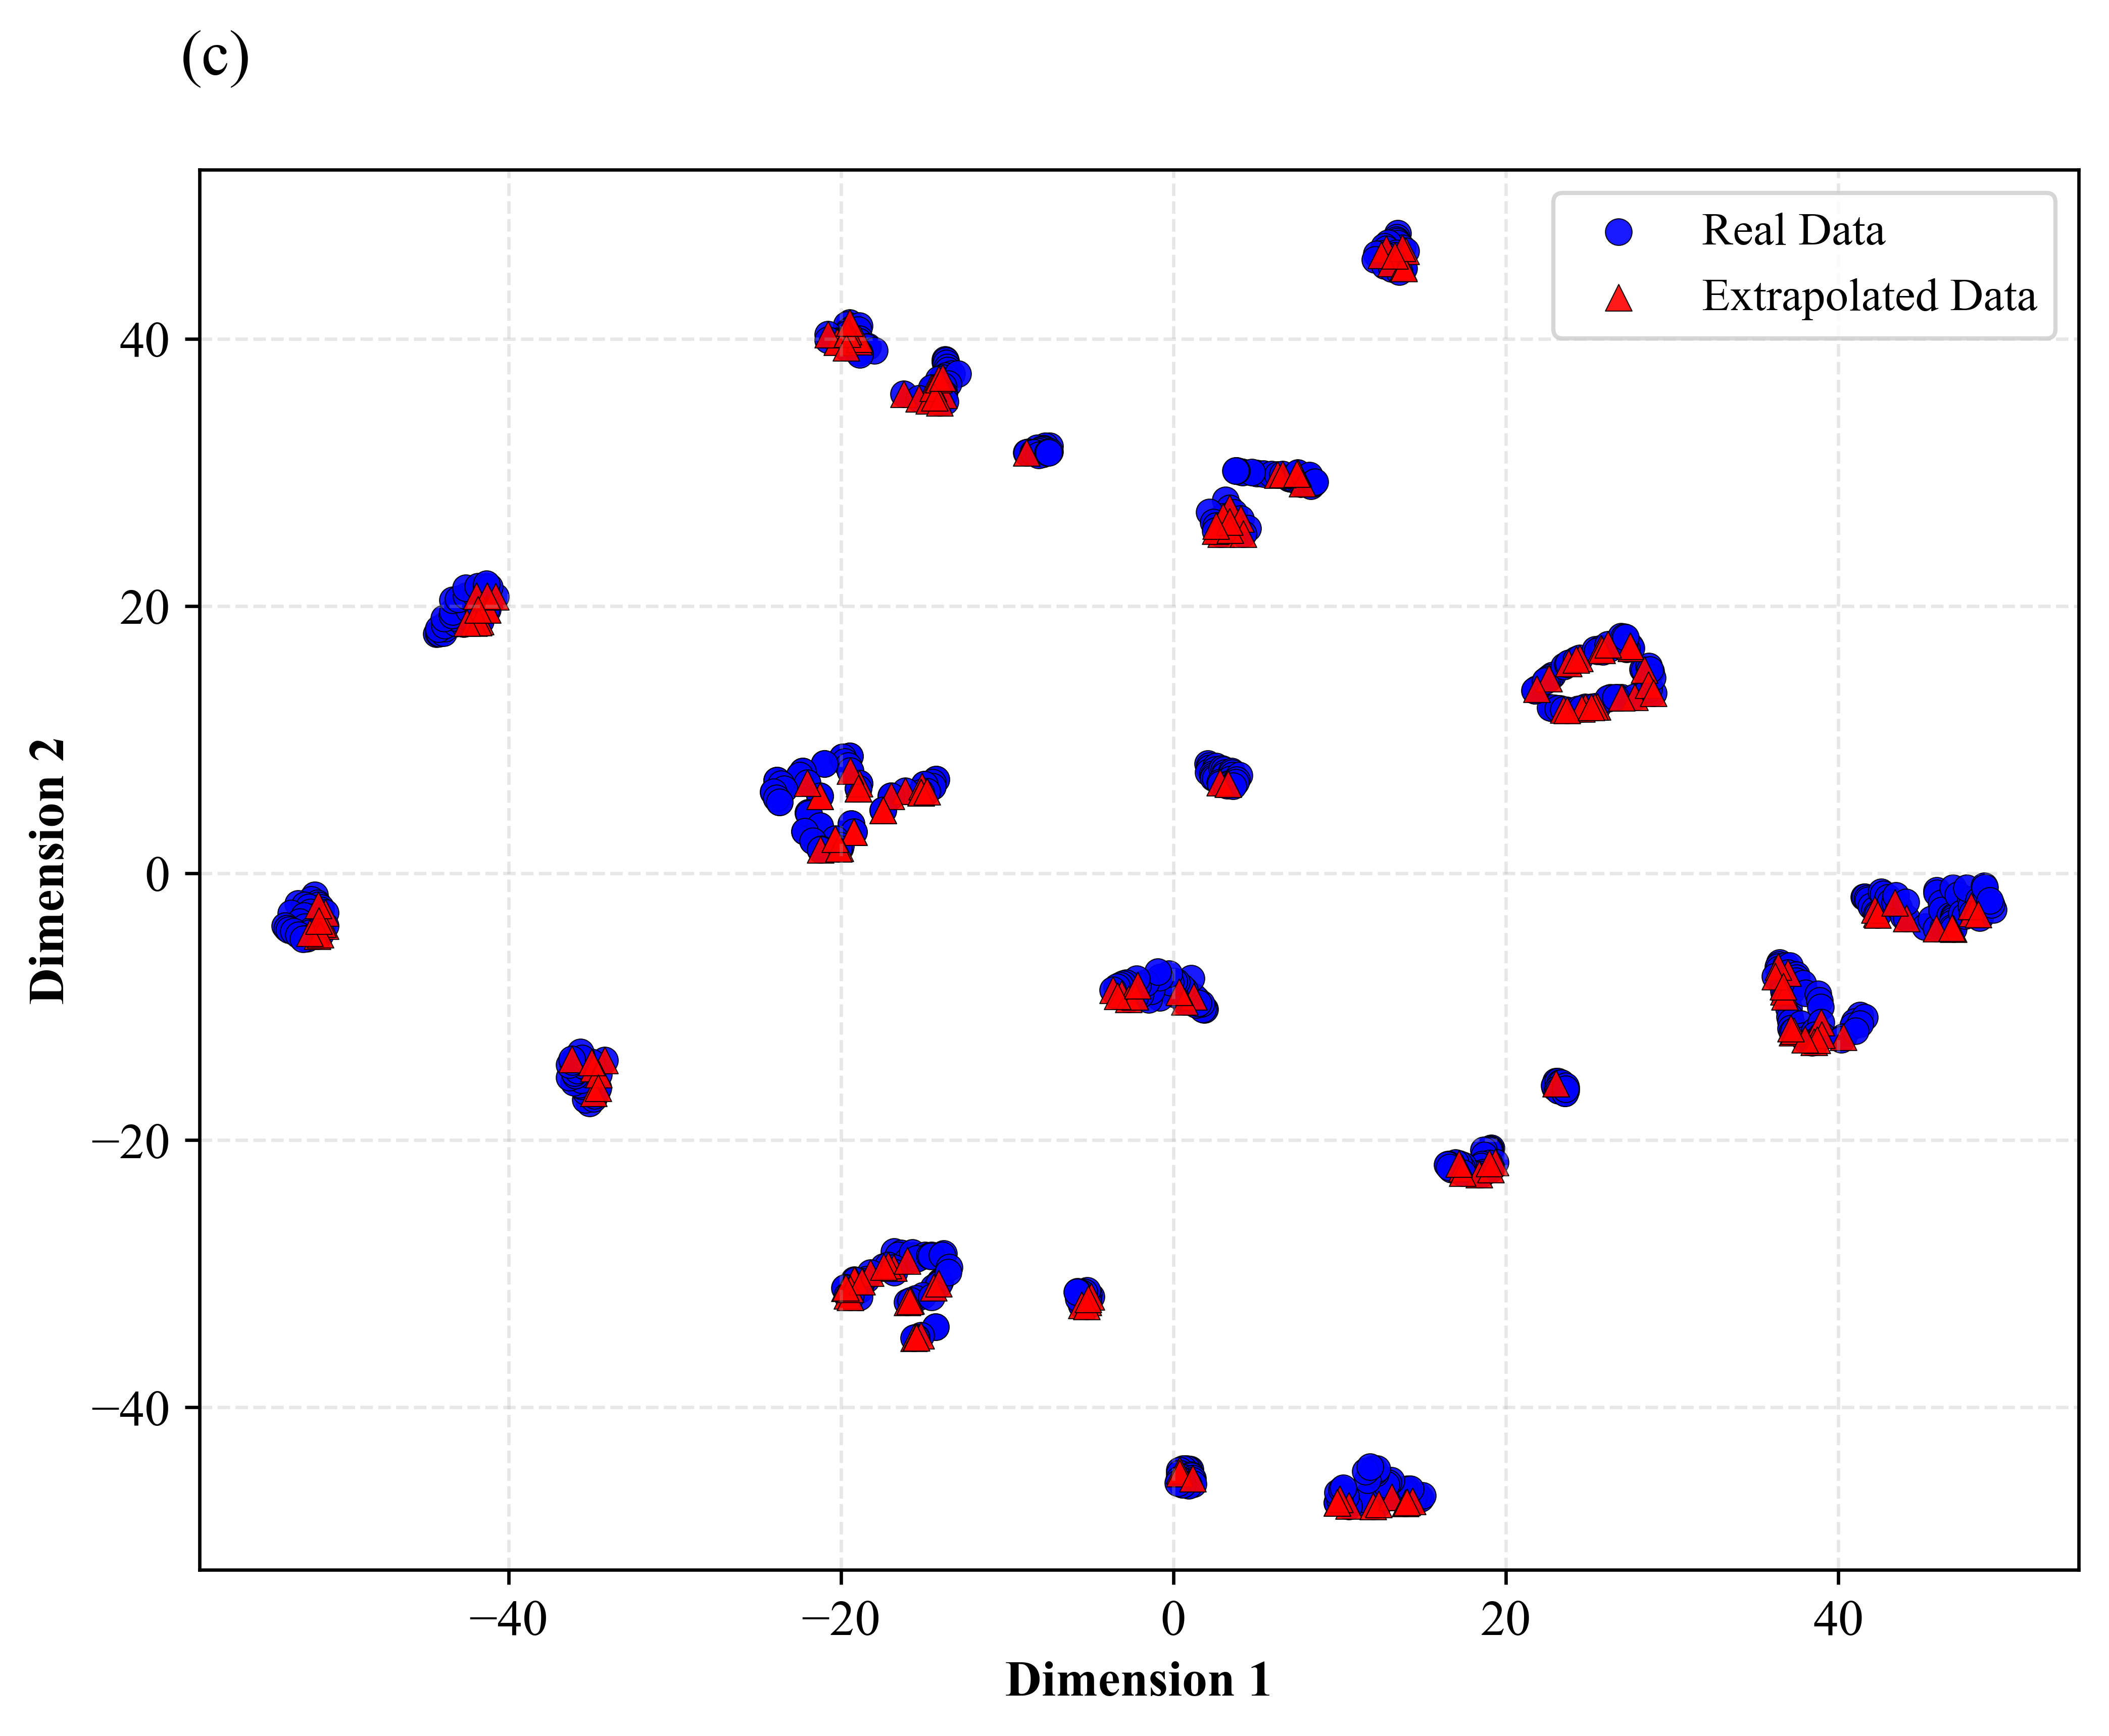

In [27]:
# 5. 可视化
plt.figure(figsize=(8, 6),dpi=600)
# 设置全局字体为 Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12  # 基础字体大小
orig_mask = tsne_df['Source'] == 'Real Data'
smogn_mask = tsne_df['Source'] == 'Extrapolated Data'

plt.scatter(tsne_df.loc[orig_mask, 'TSNE1'], tsne_df.loc[orig_mask, 'TSNE2'],
           c='blue', alpha=0.9, s=40, edgecolor="black", linewidths=0.25, 
           label='Real Data', marker='o')
plt.scatter(tsne_df.loc[smogn_mask, 'TSNE1'], tsne_df.loc[smogn_mask, 'TSNE2'],
           c='red', alpha=0.9, s=40, edgecolor="black", linewidths=0.25, 
           label='Extrapolated Data', marker='^')
ax = plt.gca()
# 添加图形编号
plt.text(-0.01, 1.1, '(c)',  # (a)是图形编号，可根据需要修改
         transform=ax.transAxes,
         fontsize=15,
         verticalalignment='top',
         horizontalalignment='left',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.xlabel('Dimension 1', fontweight='bold')
plt.ylabel('Dimension 2', fontweight='bold')

# 添加图例
legend = ax.legend(
    #frameon=True,  # 显示图例外框
    loc='upper right',  # 初始定位在左上角
    bbox_to_anchor=(1, 1),  # 精确调整位置 (x,y)
    facecolor='white',  # 图例背景色
    #edgecolor='gray',  # 图例边框颜色
    fontsize=11  # 图例字体大小
)
plt.grid(True, alpha=0.3, linestyle='--')